In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import xarray as xr

# Notebook for checking salinity anomalies at five randomly generated timesteps for May 2024

In [2]:
filepath_may_anomalies = '/lustre/storeB/project/fou/hi/foccus/malene/ocean-ai/plot/analysis'
checkpoint = 'anomalies_may.nc'


In [3]:
#open ds
ds = xr.open_dataset(f'{filepath_may_anomalies}/{checkpoint}')

In [4]:
ds

<xarray.Dataset> Size: 9GB
Dimensions:   (time: 720, X: 2747, Y: 1148)
Coordinates:
  * time      (time) datetime64[ns] 6kB 2024-05-01 ... 2024-05-31T23:00:00
    s_rho     float64 8B ...
  * X         (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y         (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.16e+05 9.168e+05 9.176e+05
    lon       (Y, X) float64 25MB ...
    lat       (Y, X) float64 25MB ...
    s_w       float64 8B ...
Data variables:
    salinity  (time, Y, X) float32 9GB ...

In [5]:
# select five random timesteps from May to check variable distribution and the anomaly field
n = 5 
random_i = np.random.randint(0, ds.sizes['time'], size = n)
random_ds = ds.isel(time = random_i)

In [6]:
print(random_ds.time)

<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['2024-05-29T17:00:00.000000000', '2024-05-20T20:00:00.000000000',
       '2024-05-30T14:00:00.000000000', '2024-05-28T07:00:00.000000000',
       '2024-05-08T12:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2024-05-29T17:00:00 ... 2024-05-08T12:...
    s_rho    float64 8B ...
    s_w      float64 8B ...
Attributes:
    long_name:      time since initialization
    field:          time, scalar, series
    axis:           T
    standard_name:  time


In [7]:
#Import the dataset with the climatology for salinity in May
file_path_avg = '/lustre/storeB/project/fou/hi/foccus/datasets/norkystv3_averages'
checkpoint_mai_mean = 'norkyst800-202405_avg.nc'
ds_clim = xr.open_dataset(f'{file_path_avg}/{checkpoint_mai_mean}')

In [8]:
#import the associated norkyst files
norkyst_gen_path = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024'

#randomly generated checkpoints of anomalies and their associated norkyst time steps
checkpoint_may_22nd = 'norkyst800-20240522.nc' #time zero
checkpoint_may_7th = 'norkyst800-20240507.nc' #05:00
checkpoint_may_15th = 'norkyst800-20240515.nc' #16:00 
checkpoint_may_6th =  'norkyst800-20240506.nc' #07:00 
checkpoint_may_23rd = 'norkyst800-20240523.nc' #06:00 


norkyst_22nd = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_22nd}').isel(s_rho = -1, time = 0)
norkyst_7th = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_7th}').isel(s_rho = -1, time = 5)
norkyst_15th = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_15th}').isel(s_rho = -1, time = 16)
norkyst_6th = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_6th}').isel(s_rho = -1, time = 7)
norkyst_23rd = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_23rd}').isel(s_rho = -1, time = 6)

In [9]:
norkyst = {
    'day22' : norkyst_22nd,
    'day7' : norkyst_7th,
    'day15' : norkyst_15th,
    'day6' : norkyst_6th, 
    'day23' : norkyst_23rd
}

"""
#select salinity values
nor_plot = {}
for day, data in norkyst.items():
    nor_plot[day] = data.salinity.values
"""

'\n#select salinity values\nnor_plot = {}\nfor day, data in norkyst.items():\n    nor_plot[day] = data.salinity.values\n'

In [10]:
anomalies_g = {
    'day22' : random_ds.salinity.isel(time = 0).values,
    'day7' : random_ds.salinity.isel(time = 1).values,
    'day15' : random_ds.salinity.isel(time = 2).values,
    'day6' : random_ds.salinity.isel(time = 3).values,
    'day23' : random_ds.salinity.isel(time = 4).values,
}

In [11]:
import cartopy
import cmocean #using haline cmocean color 
import cartopy.crs as ccrs #cartopy north stereo

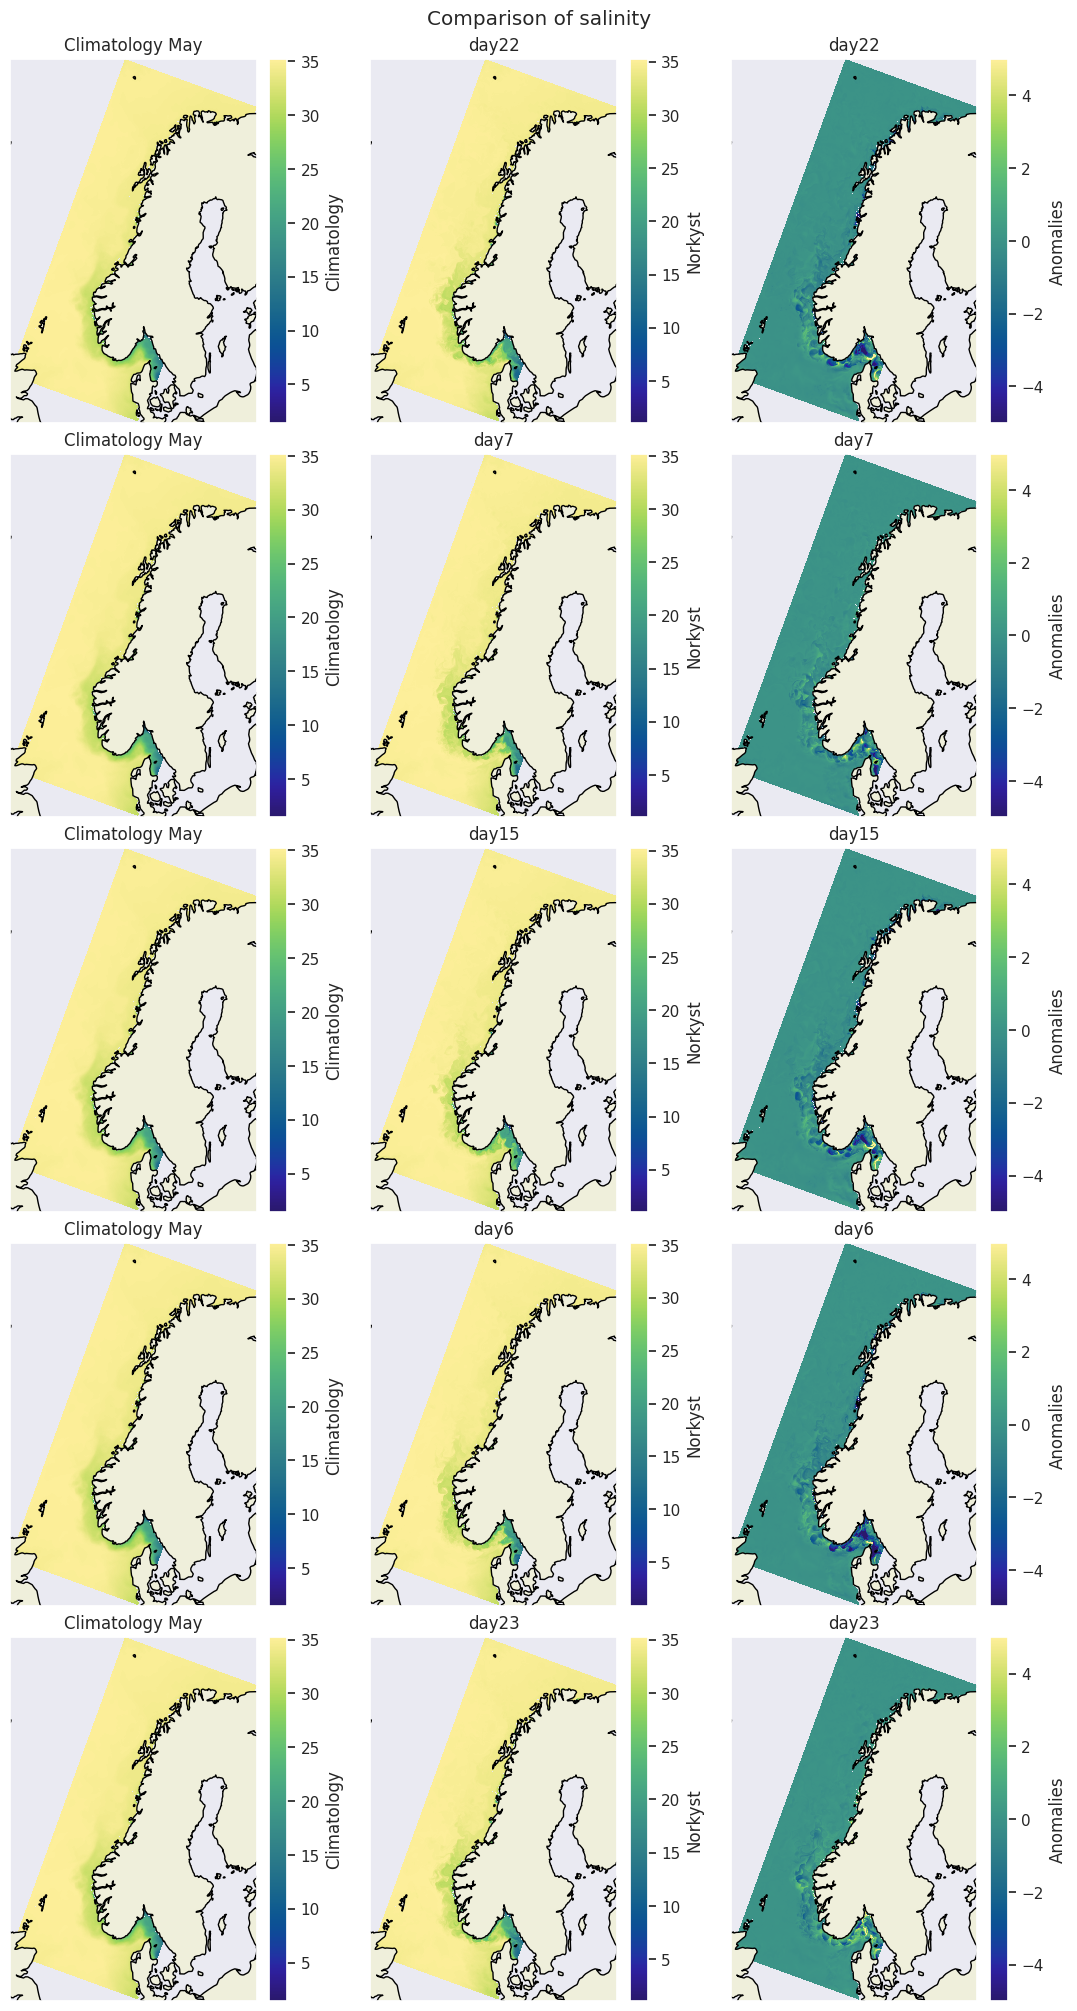

In [ ]:
n_plots = len(norkyst) #5 tidssteg 
columns = 3
fig, axes = plt.subplots(n_plots, columns, figsize = (40,4*n_plots), layout = 'compressed', subplot_kw= { 'projection' : ccrs.NorthPolarStereo()})
if n_plots == 1:
    axes = [axes] 

for i, (day, data_nor) in enumerate(norkyst.items()):
    anomaly = anomalies_g.get(day, None)
    norkyst_salinity = data_nor.salinity.values
    anomaly_salinity = anomaly if anomaly is not None else np.zeros_like(norkyst_salinity) #if day is missing, a np zeros will be used instead

    #pick out lon and lat
    lon = ds_clim.lon.values
    lat = ds_clim.lat.values

    #im1
    ax_clim = axes[i][0]
    im1 = ax_clim.pcolormesh(lon, lat, ds_clim.salinity.values, cmap = cmocean.cm.haline, transform = ccrs.PlateCarree())
    ax_clim.set_title(f'Climatology May') 
    ax_clim.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
    cbar1 = fig.colorbar(im1, ax=ax_clim, orientation = 'vertical')
    cbar1.set_label('Climatology', fontsize = 12)

    #im2
    ax_norkyst = axes[i][1]
    im2 = ax_norkyst.pcolormesh(lon, lat, norkyst_salinity, cmap = cmocean.cm.haline, transform = ccrs.PlateCarree())
    ax_norkyst.set_title(f'{day}') 
    ax_norkyst.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
    cbar2 = fig.colorbar(im2, ax=ax_norkyst, orientation = 'vertical')
    cbar2.set_label('Norkyst', fontsize = 12)

    #im3
    ax_anomaly = axes[i][2]
    im3 = ax_anomaly.pcolormesh(lon, lat, anomaly_salinity, cmap = cmocean.cm.haline, transform = ccrs.PlateCarree(), vmin = -5, vmax = 5)
    ax_anomaly.set_title(f'{day}') 
    ax_anomaly.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
    cbar2 = fig.colorbar(im3, ax=ax_anomaly, orientation = 'vertical')
    cbar2.set_label('Anomalies', fontsize = 12)

    for ax in [ax_clim, ax_norkyst, ax_anomaly]:
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Longitude')

plt.suptitle(f'Comparison of salinity')
plt.show()



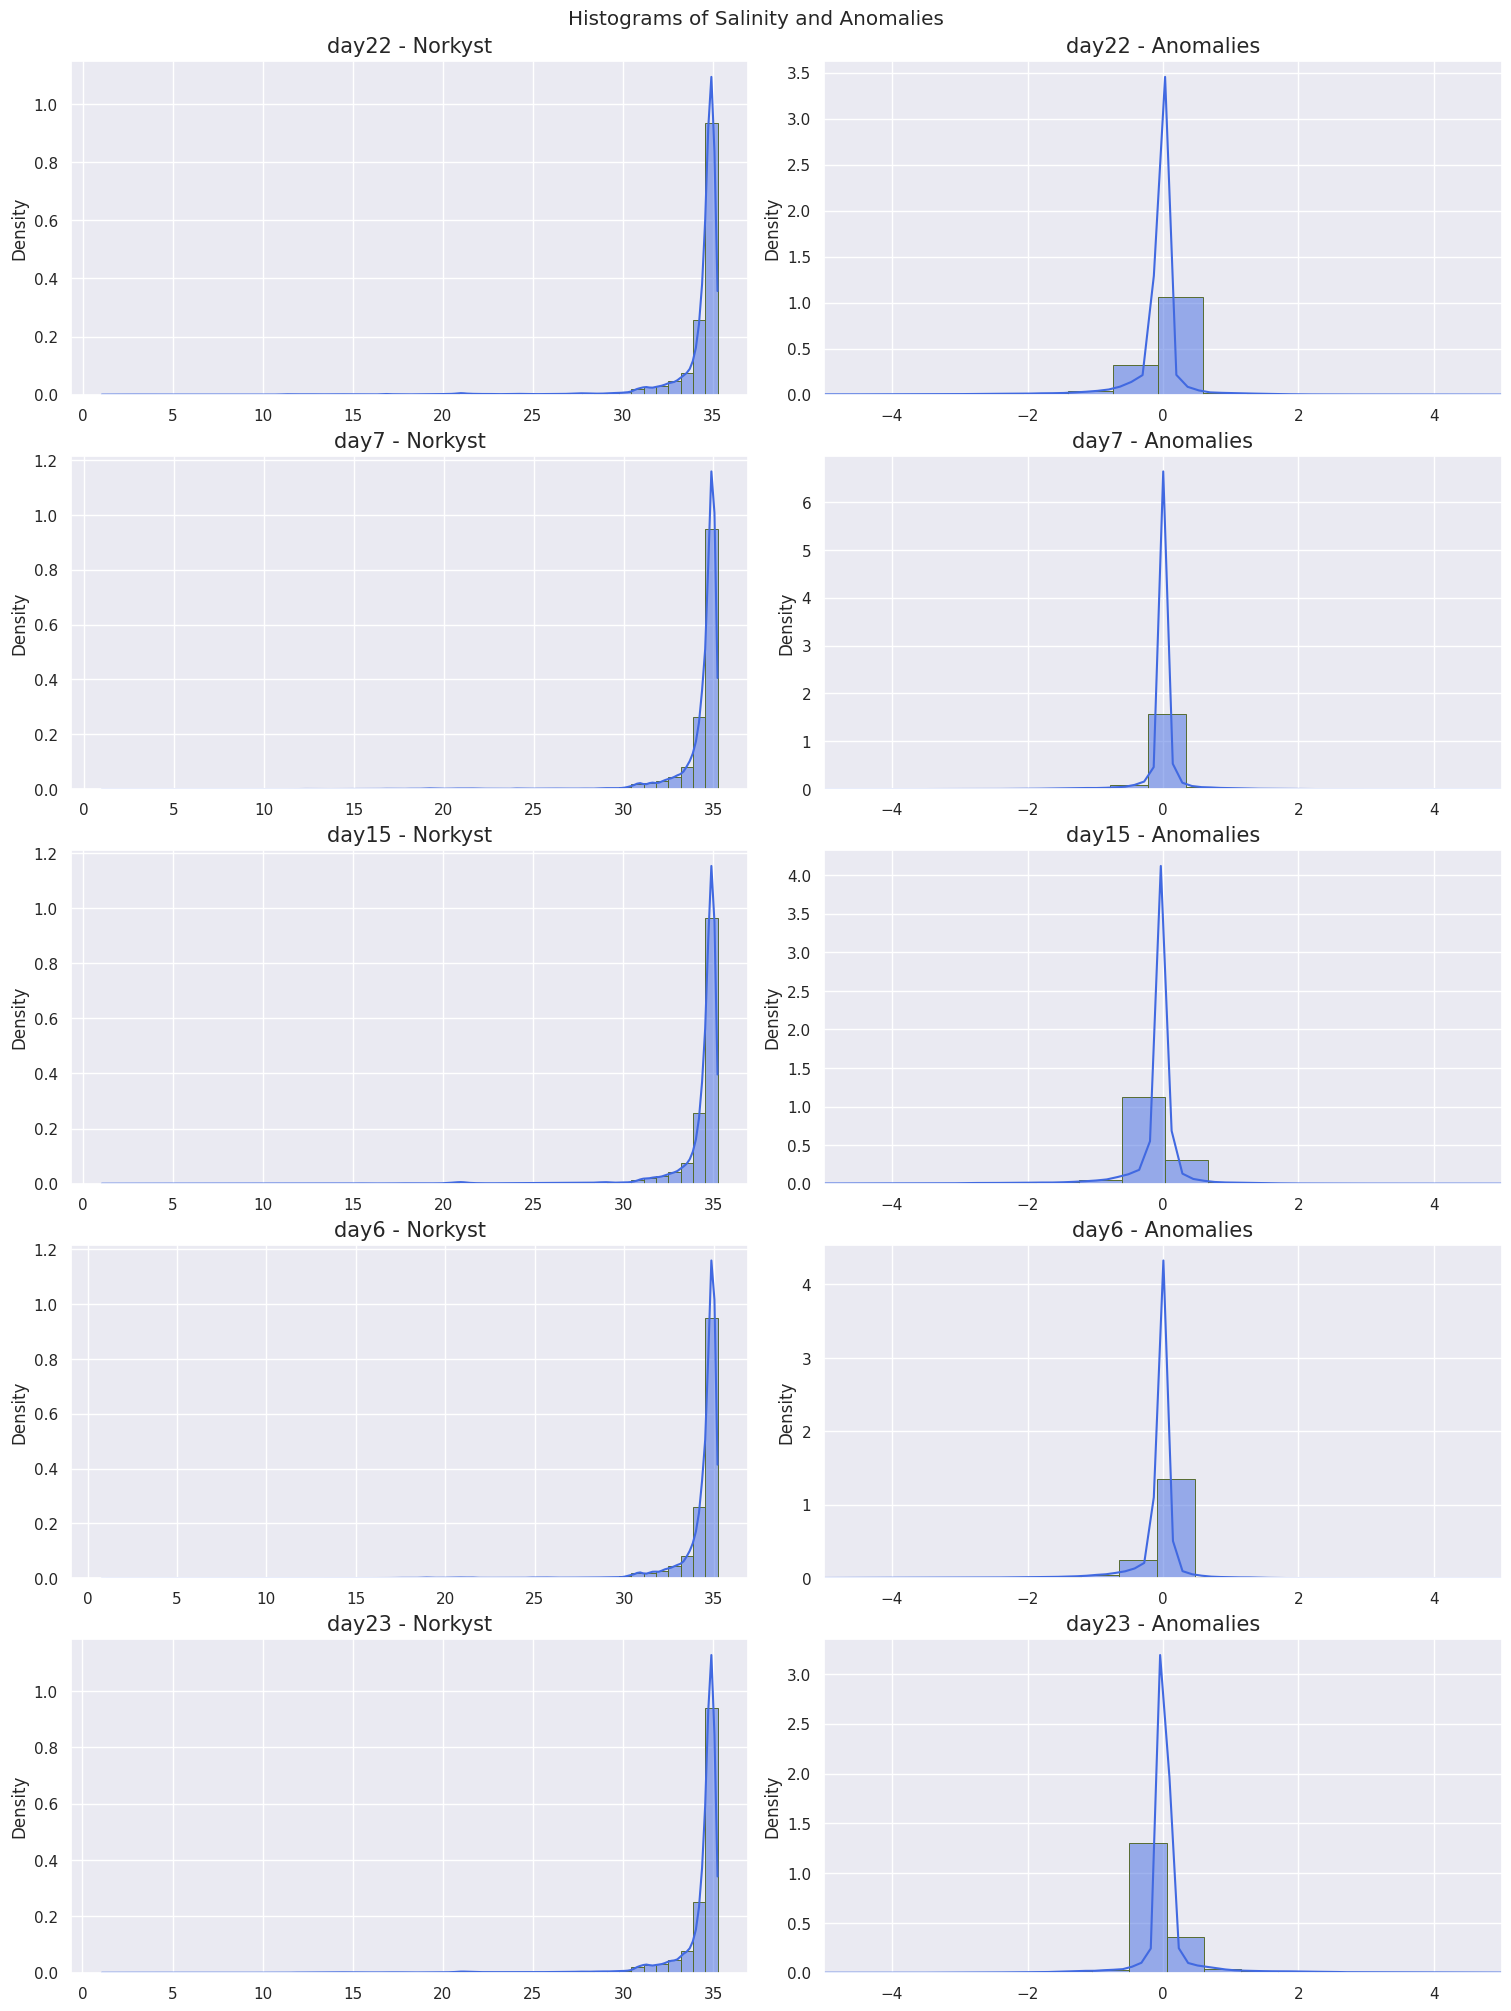

In [ ]:
#now lets check the distribution of the variables 

sns.set_theme(style='darkgrid')
columns_hist = 2 
fig, axes = plt.subplots(n_plots, columns_hist, figsize = (15, 20), layout = 'compressed')

for i, (day, data_nor) in enumerate(norkyst.items()):
    anomaly = anomalies_g.get(day, None)
    norkyst_salinity = data_nor.salinity.values
    anomaly_salinity = anomaly if anomaly is not None else np.zeros_like(norkyst_salinity) #if day is missing, a np zeros will be used instead

    #remove nans 
    norkyst_salinity[~np.isnan(norkyst_salinity)]
    anomaly_salinity[~np.isnan(anomaly_salinity)]

    #ravel
    norkyst_salinity = norkyst_salinity.ravel()
    anomaly_salinity = anomaly_salinity.ravel()

    #im1 
    ax_norkyst_hist = axes[i][0]
    im1 = sns.histplot(norkyst_salinity, bins = 50, kde = True, ax = ax_norkyst_hist, stat = 'density', color = 'royalblue', edgecolor = 'darkolivegreen')
    ax_norkyst_hist.set_title(f'{day} - Norkyst', fontsize = 15)

    #im2
    ax_anomalies = axes[i][1]
    im1 = sns.histplot(anomaly_salinity, bins = 50, kde = True, ax = ax_anomalies, stat = 'density', color = 'royalblue', edgecolor = 'darkolivegreen')
    ax_anomalies.set_title(f'{day} - Anomalies', fontsize = 15)
    ax_anomalies.set_xlim(-5,5)

plt.suptitle(f'Histograms of Salinity and Anomalies')
plt.show()

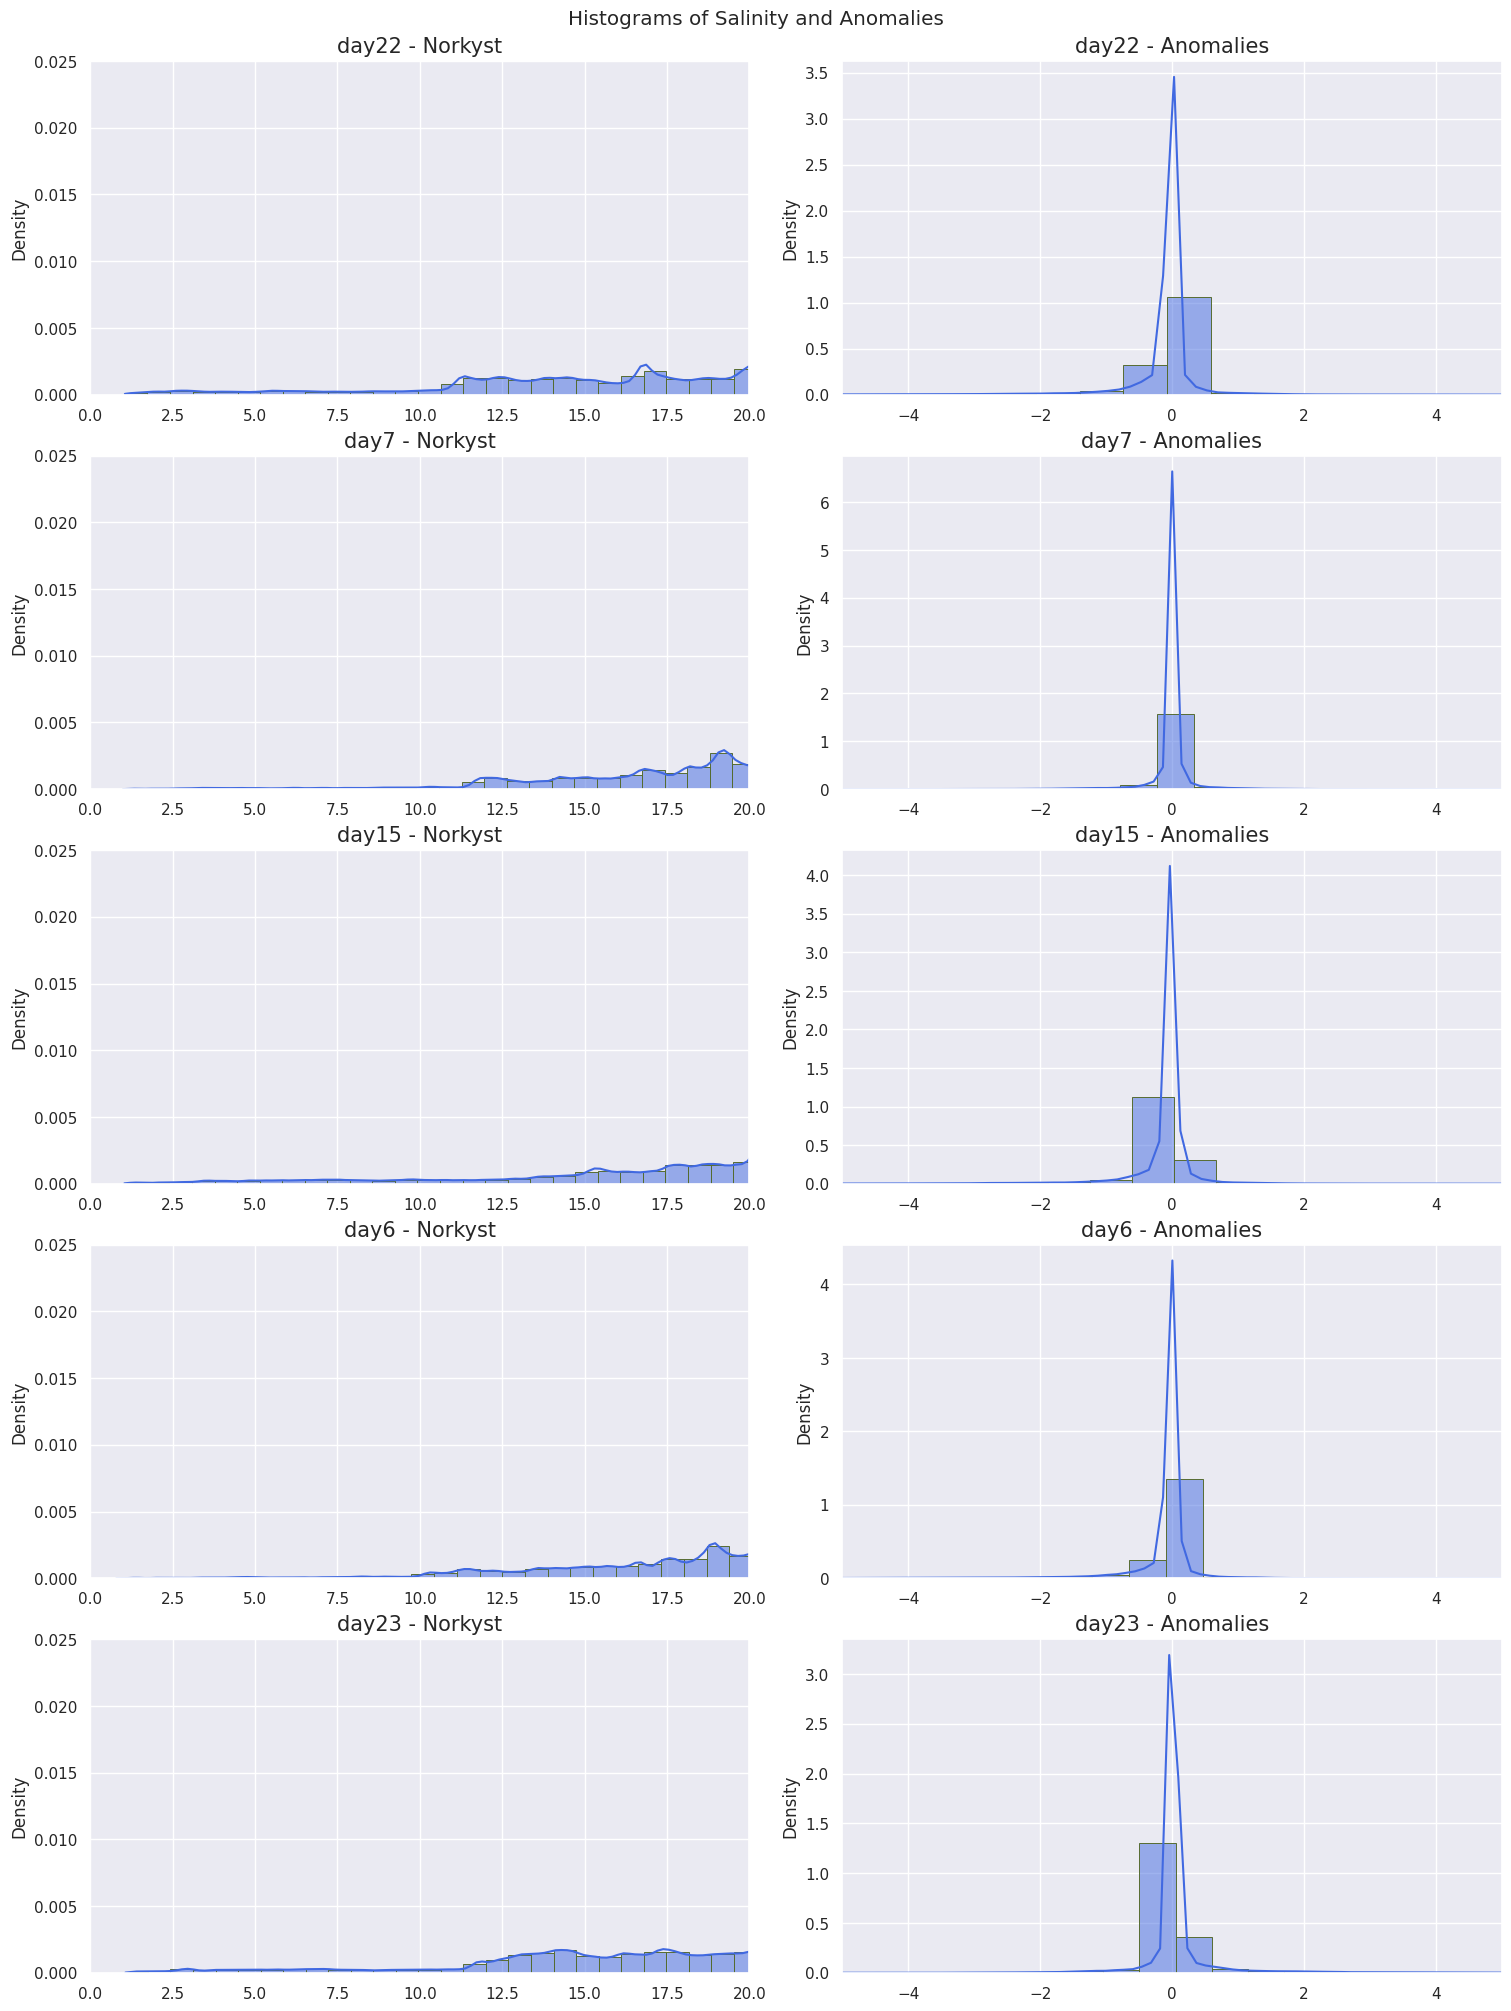

In [20]:
#repeat and check for cut-off + how the scalings are 

sns.set_theme(style='darkgrid')
columns_hist = 2 
fig, axes = plt.subplots(n_plots, columns_hist, figsize = (15, 20), layout = 'compressed')

for i, (day, data_nor) in enumerate(norkyst.items()):
    anomaly = anomalies_g.get(day, None)
    norkyst_salinity = data_nor.salinity.values
    anomaly_salinity = anomaly if anomaly is not None else np.zeros_like(norkyst_salinity) #if day is missing, a np zeros will be used instead

    #remove nans 
    norkyst_salinity[~np.isnan(norkyst_salinity)]
    anomaly_salinity[~np.isnan(anomaly_salinity)]

    #ravel
    norkyst_salinity = norkyst_salinity.ravel()
    anomaly_salinity = anomaly_salinity.ravel()

    #im1 
    ax_norkyst_hist = axes[i][0]
    im1 = sns.histplot(norkyst_salinity, bins = 50, kde = True, ax = ax_norkyst_hist, stat = 'density', color = 'royalblue', edgecolor = 'darkolivegreen')
    ax_norkyst_hist.set_title(f'{day} - Norkyst', fontsize = 15)
    ax_norkyst_hist.set_xlim(0,20)
    ax_norkyst_hist.set_ylim(0, 0.025)

    #im2
    ax_anomalies = axes[i][1]
    im1 = sns.histplot(anomaly_salinity, bins = 50, kde = True, ax = ax_anomalies, stat = 'density', color = 'royalblue', edgecolor = 'darkolivegreen')
    ax_anomalies.set_title(f'{day} - Anomalies', fontsize = 15)
    ax_anomalies.set_xlim(-5,5)

plt.suptitle(f'Histograms of Salinity and Anomalies')
plt.show()

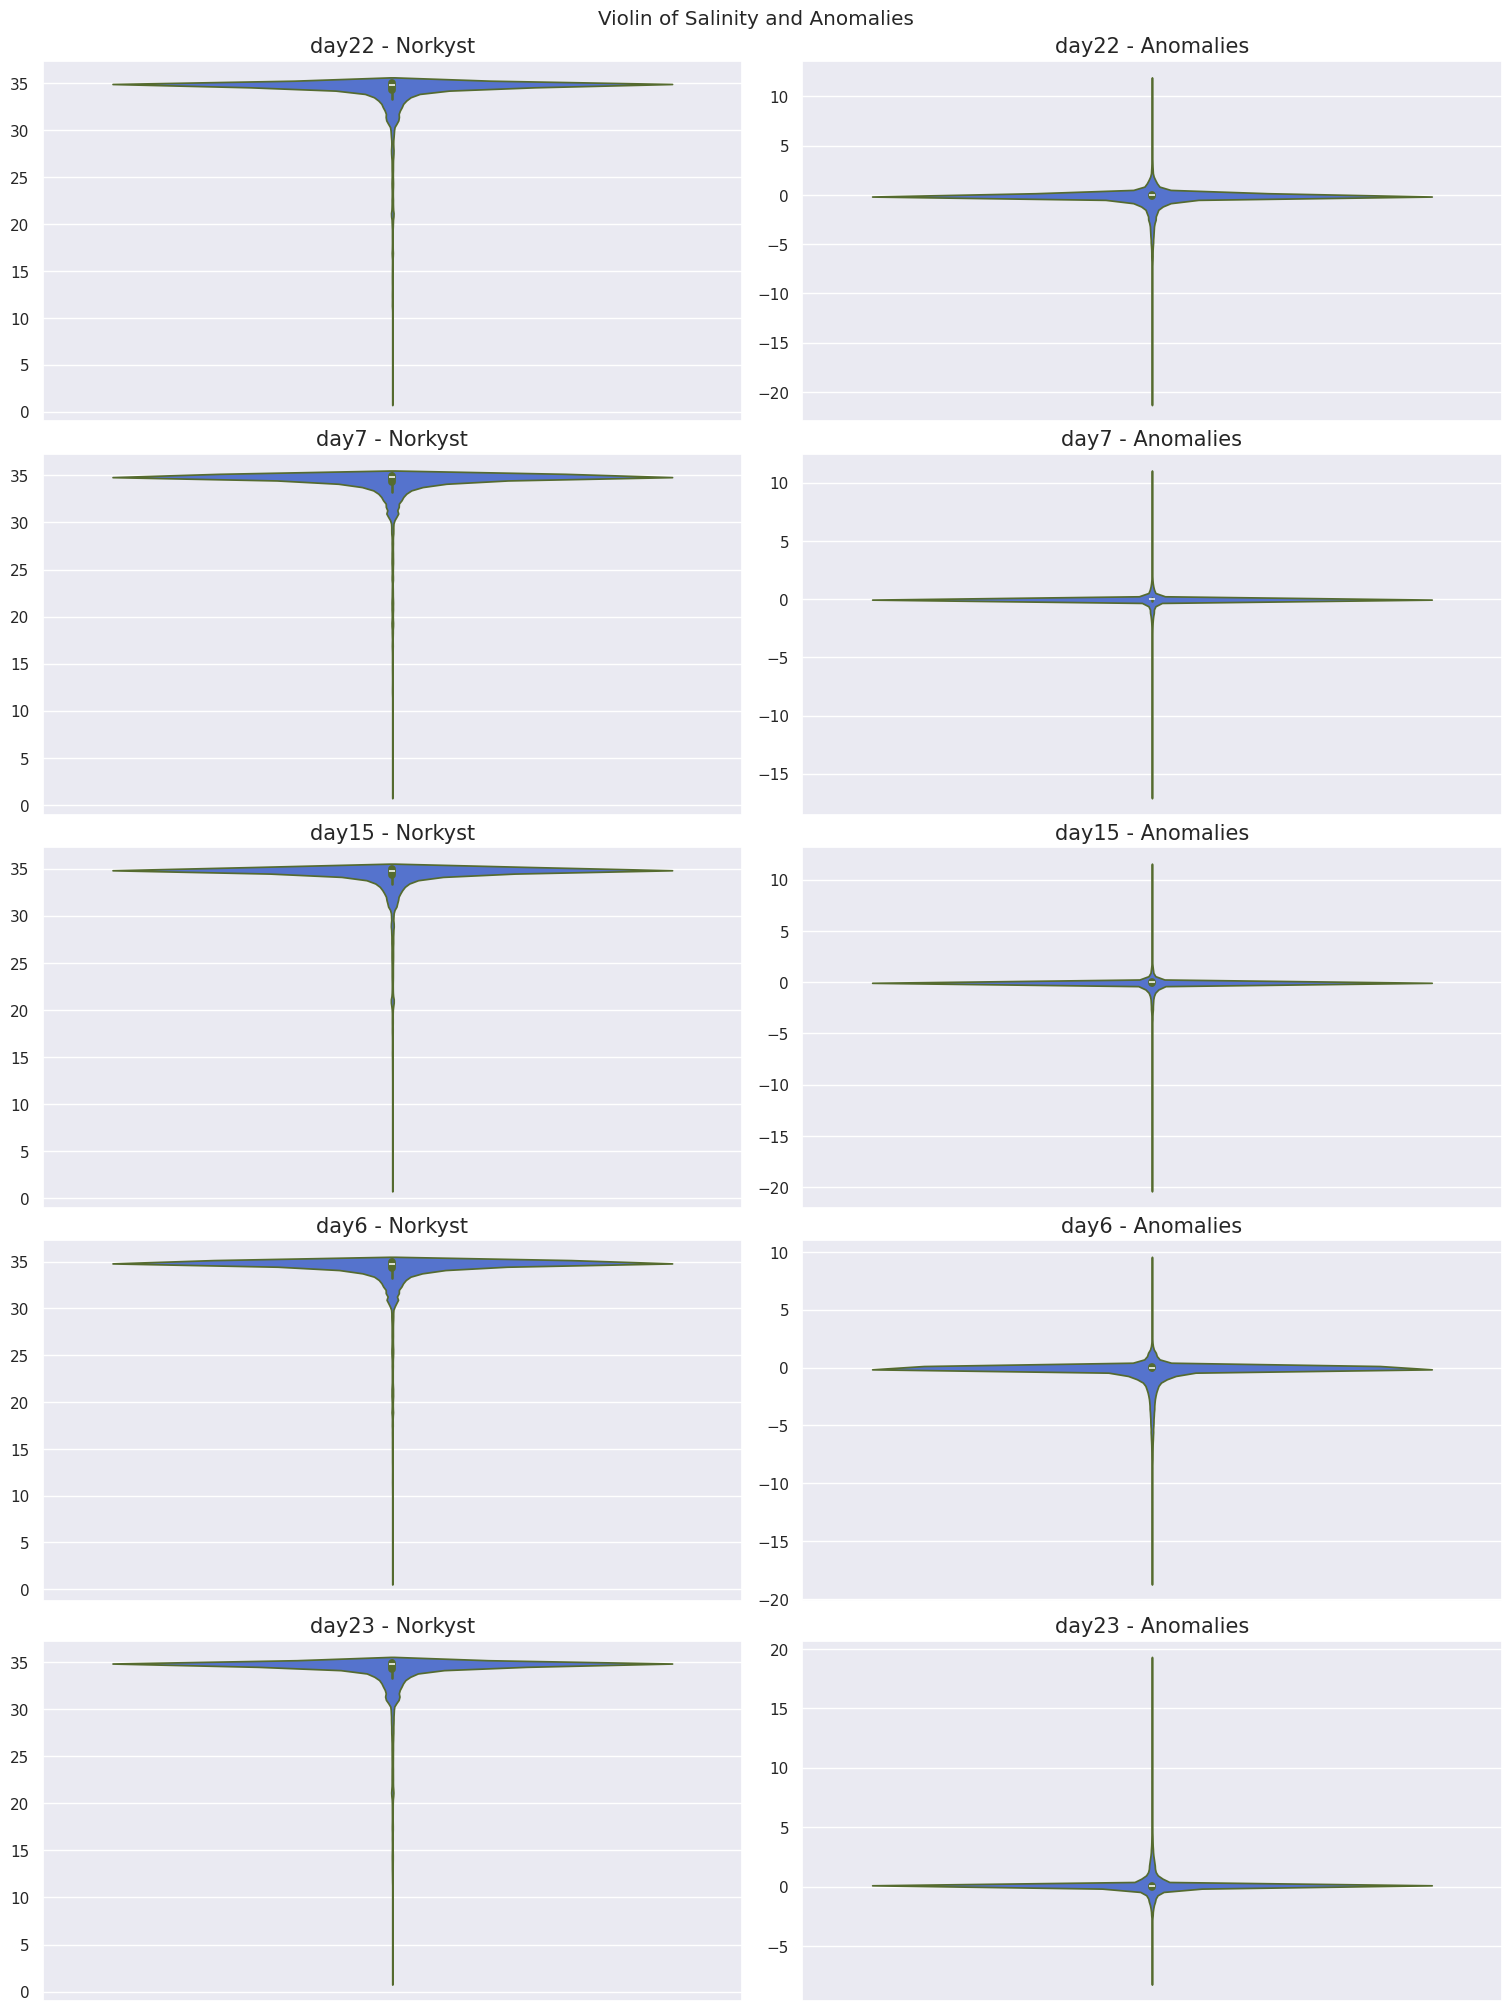

In [23]:
sns.set_theme(style='darkgrid')
columns_hist = 2 
fig, axes = plt.subplots(n_plots, columns_hist, figsize = (15, 20), layout = 'compressed')

for i, (day, data_nor) in enumerate(norkyst.items()):
    anomaly = anomalies_g.get(day, None)
    norkyst_salinity = data_nor.salinity.values
    anomaly_salinity = anomaly if anomaly is not None else np.zeros_like(norkyst_salinity) #if day is missing, a np zeros will be used instead

    #remove nans 
    norkyst_salinity[~np.isnan(norkyst_salinity)]
    anomaly_salinity[~np.isnan(anomaly_salinity)]

    #ravel
    norkyst_salinity = norkyst_salinity.ravel()
    anomaly_salinity = anomaly_salinity.ravel()

    #im1 
    ax_norkyst_v = axes[i][0]
    im1 = sns.violinplot(norkyst_salinity, ax = ax_norkyst_v, color = 'royalblue', edgecolor = 'darkolivegreen')
    ax_norkyst_v.set_title(f'{day} - Norkyst', fontsize = 15)

    #im2
    ax_anomalies_v = axes[i][1]
    im1 = sns.violinplot(anomaly_salinity, ax = ax_anomalies_v, color = 'royalblue', edgecolor = 'darkolivegreen')
    ax_anomalies_v.set_title(f'{day} - Anomalies', fontsize = 15)

plt.suptitle(f'Violin of Salinity and Anomalies')
plt.show()